Student score predictor

1. loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
print('loading your data...')
df = pd.read_csv('/content/student-por.csv')

print('sucessfully loaded your data...')
print(f'your data has {df.shape[0]} rows and {df.shape[1]} columns')

loading your data...
sucessfully loaded your data...
your data has 649 rows and 33 columns


2.  understanding the data

In [4]:
#data looks like
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [5]:
# columns we have
li_of_columns = {col for col in df.columns}
print('features are')
li_of_columns

features are


{'Dalc',
 'Fedu',
 'Fjob',
 'G1',
 'G2',
 'G3',
 'Medu',
 'Mjob',
 'Pstatus',
 'Walc',
 'absences',
 'activities',
 'address',
 'age',
 'failures',
 'famrel',
 'famsize',
 'famsup',
 'freetime',
 'goout',
 'guardian',
 'health',
 'higher',
 'internet',
 'nursery',
 'paid',
 'reason',
 'romantic',
 'school',
 'schoolsup',
 'sex',
 'studytime',
 'traveltime'}

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [7]:
df.isna().sum() # no null values

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [10]:
df.sample(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
542,MS,F,16,U,GT3,T,4,4,teacher,services,...,5,3,5,1,4,5,1,10,11,12
84,GP,F,15,U,GT3,T,1,1,other,other,...,4,3,2,2,3,4,2,13,12,12
617,MS,F,18,U,LE3,T,1,1,at_home,services,...,5,3,2,1,1,4,0,19,17,18
589,MS,F,17,U,LE3,T,1,2,at_home,other,...,5,5,1,1,1,3,0,7,10,10
423,MS,F,16,U,GT3,T,1,3,at_home,other,...,4,3,3,1,3,5,11,10,11,11


3. data cleaning

In [11]:
df['grade'] = df['G1'] + df['G2'] + df['G3']
df.drop(['G1', 'G2', 'G3'], axis=1, inplace=True)

In [12]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if col not in cat_cols]

In [13]:
df[num_cols]

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,grade
0,18,4,4,2,2,0,4,3,4,1,1,3,4,22
1,17,1,1,1,2,0,5,3,3,1,1,3,2,31
2,15,1,1,1,2,0,4,3,2,2,3,3,6,37
3,15,4,2,1,3,0,3,2,2,1,1,5,0,42
4,16,3,3,1,2,0,4,3,2,1,2,5,0,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,19,2,3,1,3,1,5,4,2,1,2,5,4,31
645,18,3,1,1,2,0,4,3,4,1,1,1,4,46
646,18,1,1,2,2,0,1,1,1,1,1,5,6,32
647,17,3,1,2,1,0,2,4,5,3,4,2,6,30


In [14]:
df[cat_cols]

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,no,no,yes,yes,yes,no
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,no,yes,yes,yes,yes,yes
4,GP,F,U,GT3,T,other,other,home,father,no,yes,no,no,yes,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,R,GT3,T,services,other,course,mother,no,no,no,yes,no,yes,yes,no
645,MS,F,U,LE3,T,teacher,services,course,mother,no,yes,no,no,yes,yes,yes,no
646,MS,F,U,GT3,T,other,other,course,mother,no,no,no,yes,yes,yes,no,no
647,MS,M,U,LE3,T,services,services,course,mother,no,no,no,no,no,yes,yes,no


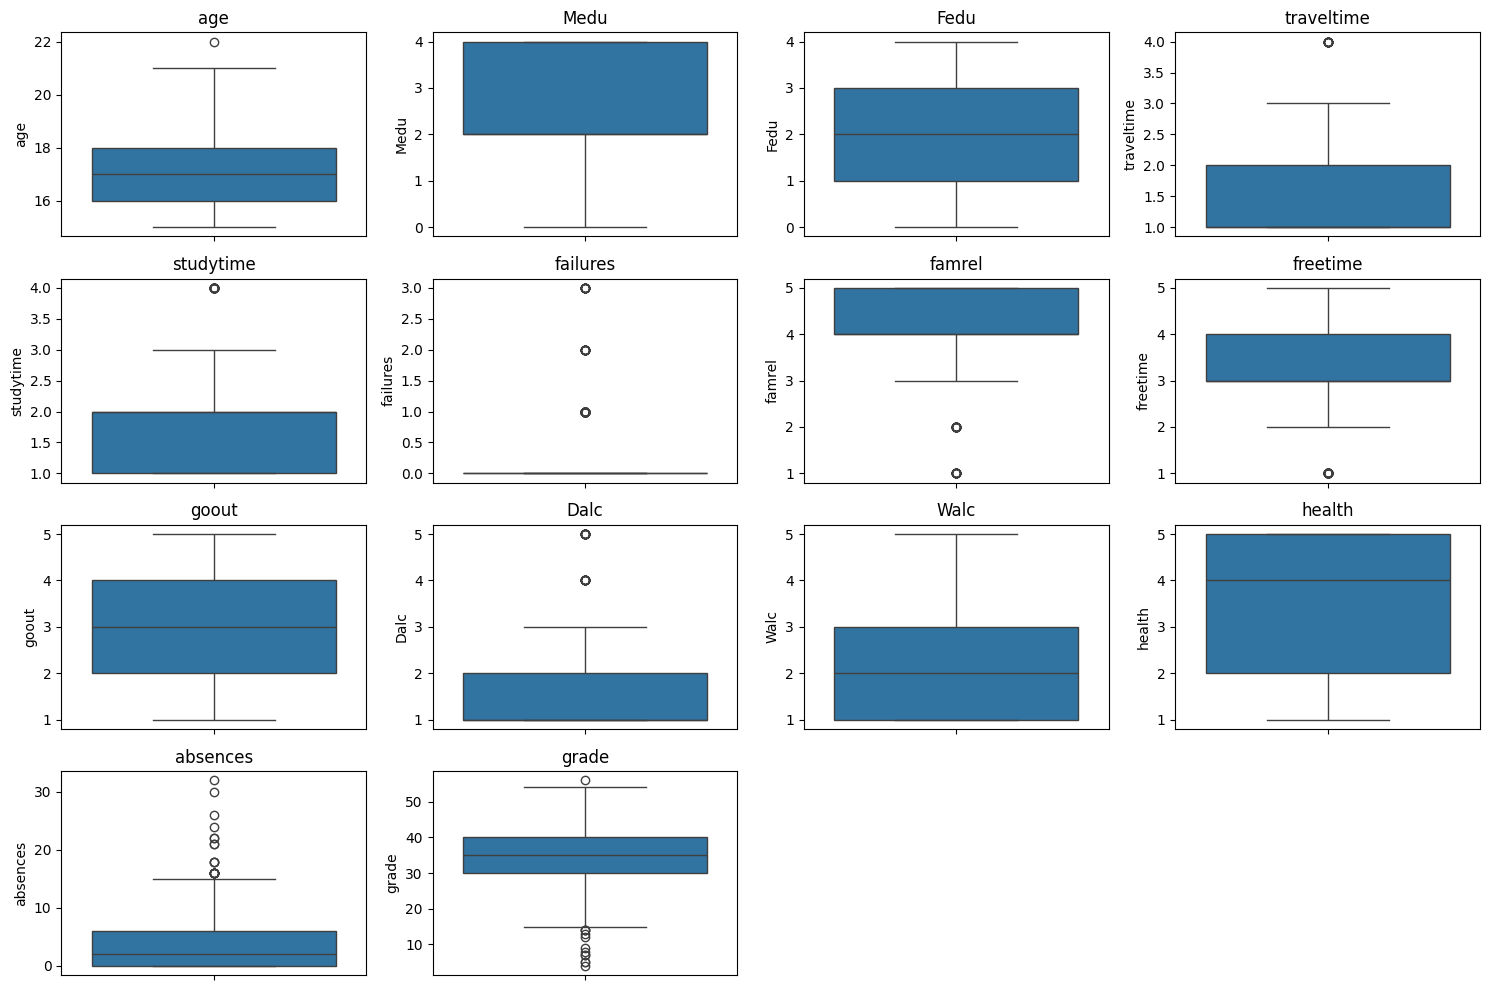

In [15]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

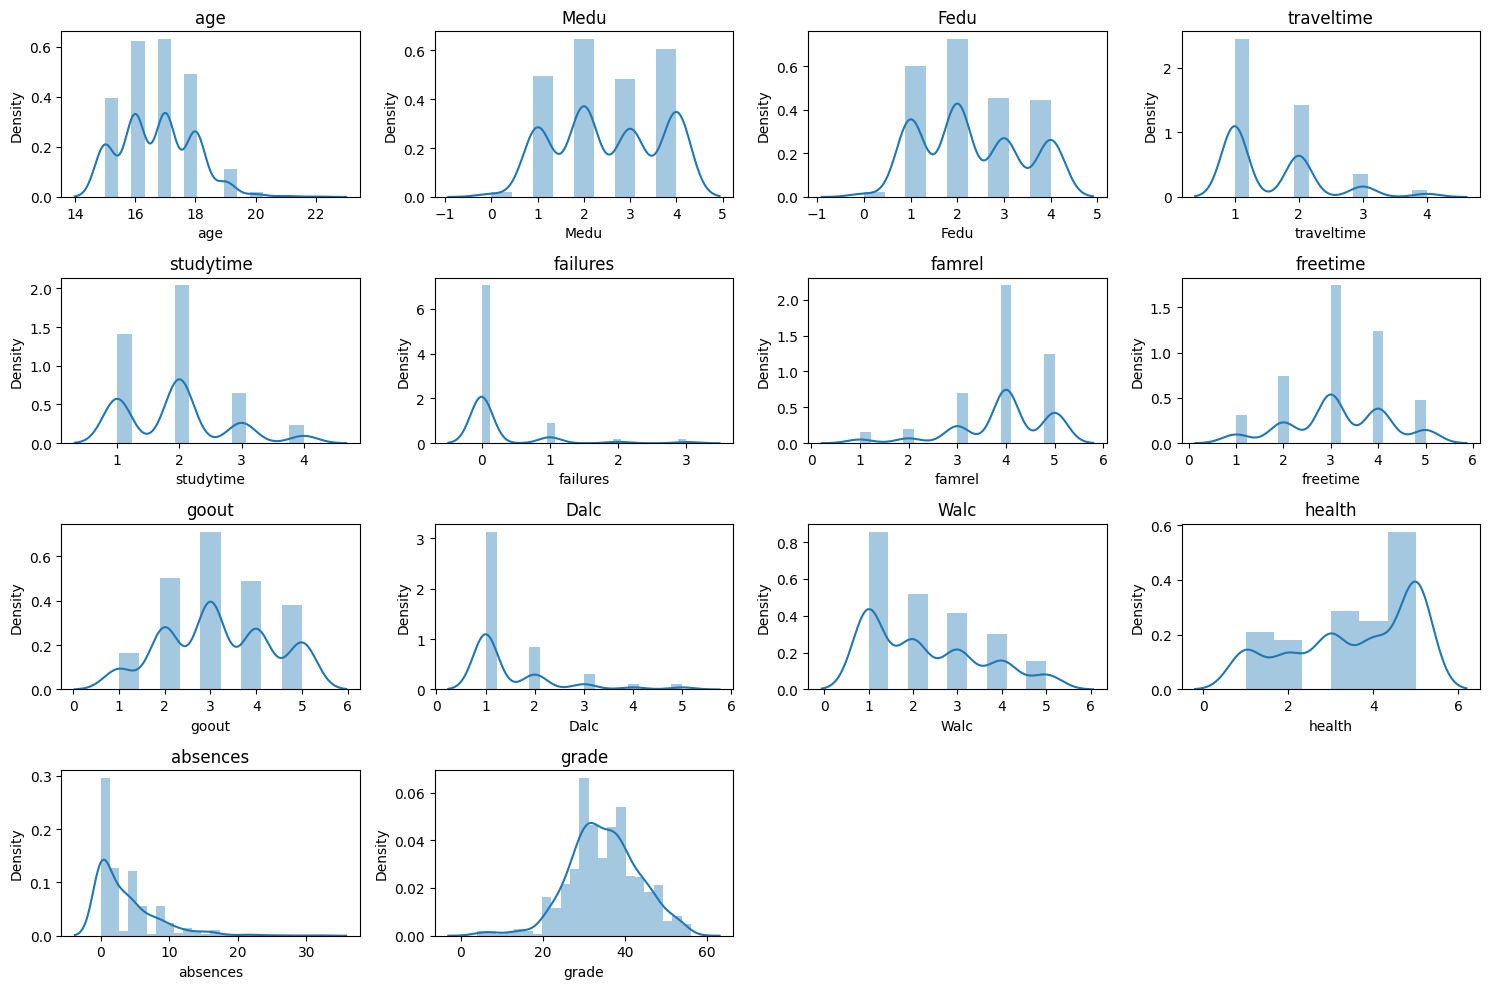

In [16]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.distplot(df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

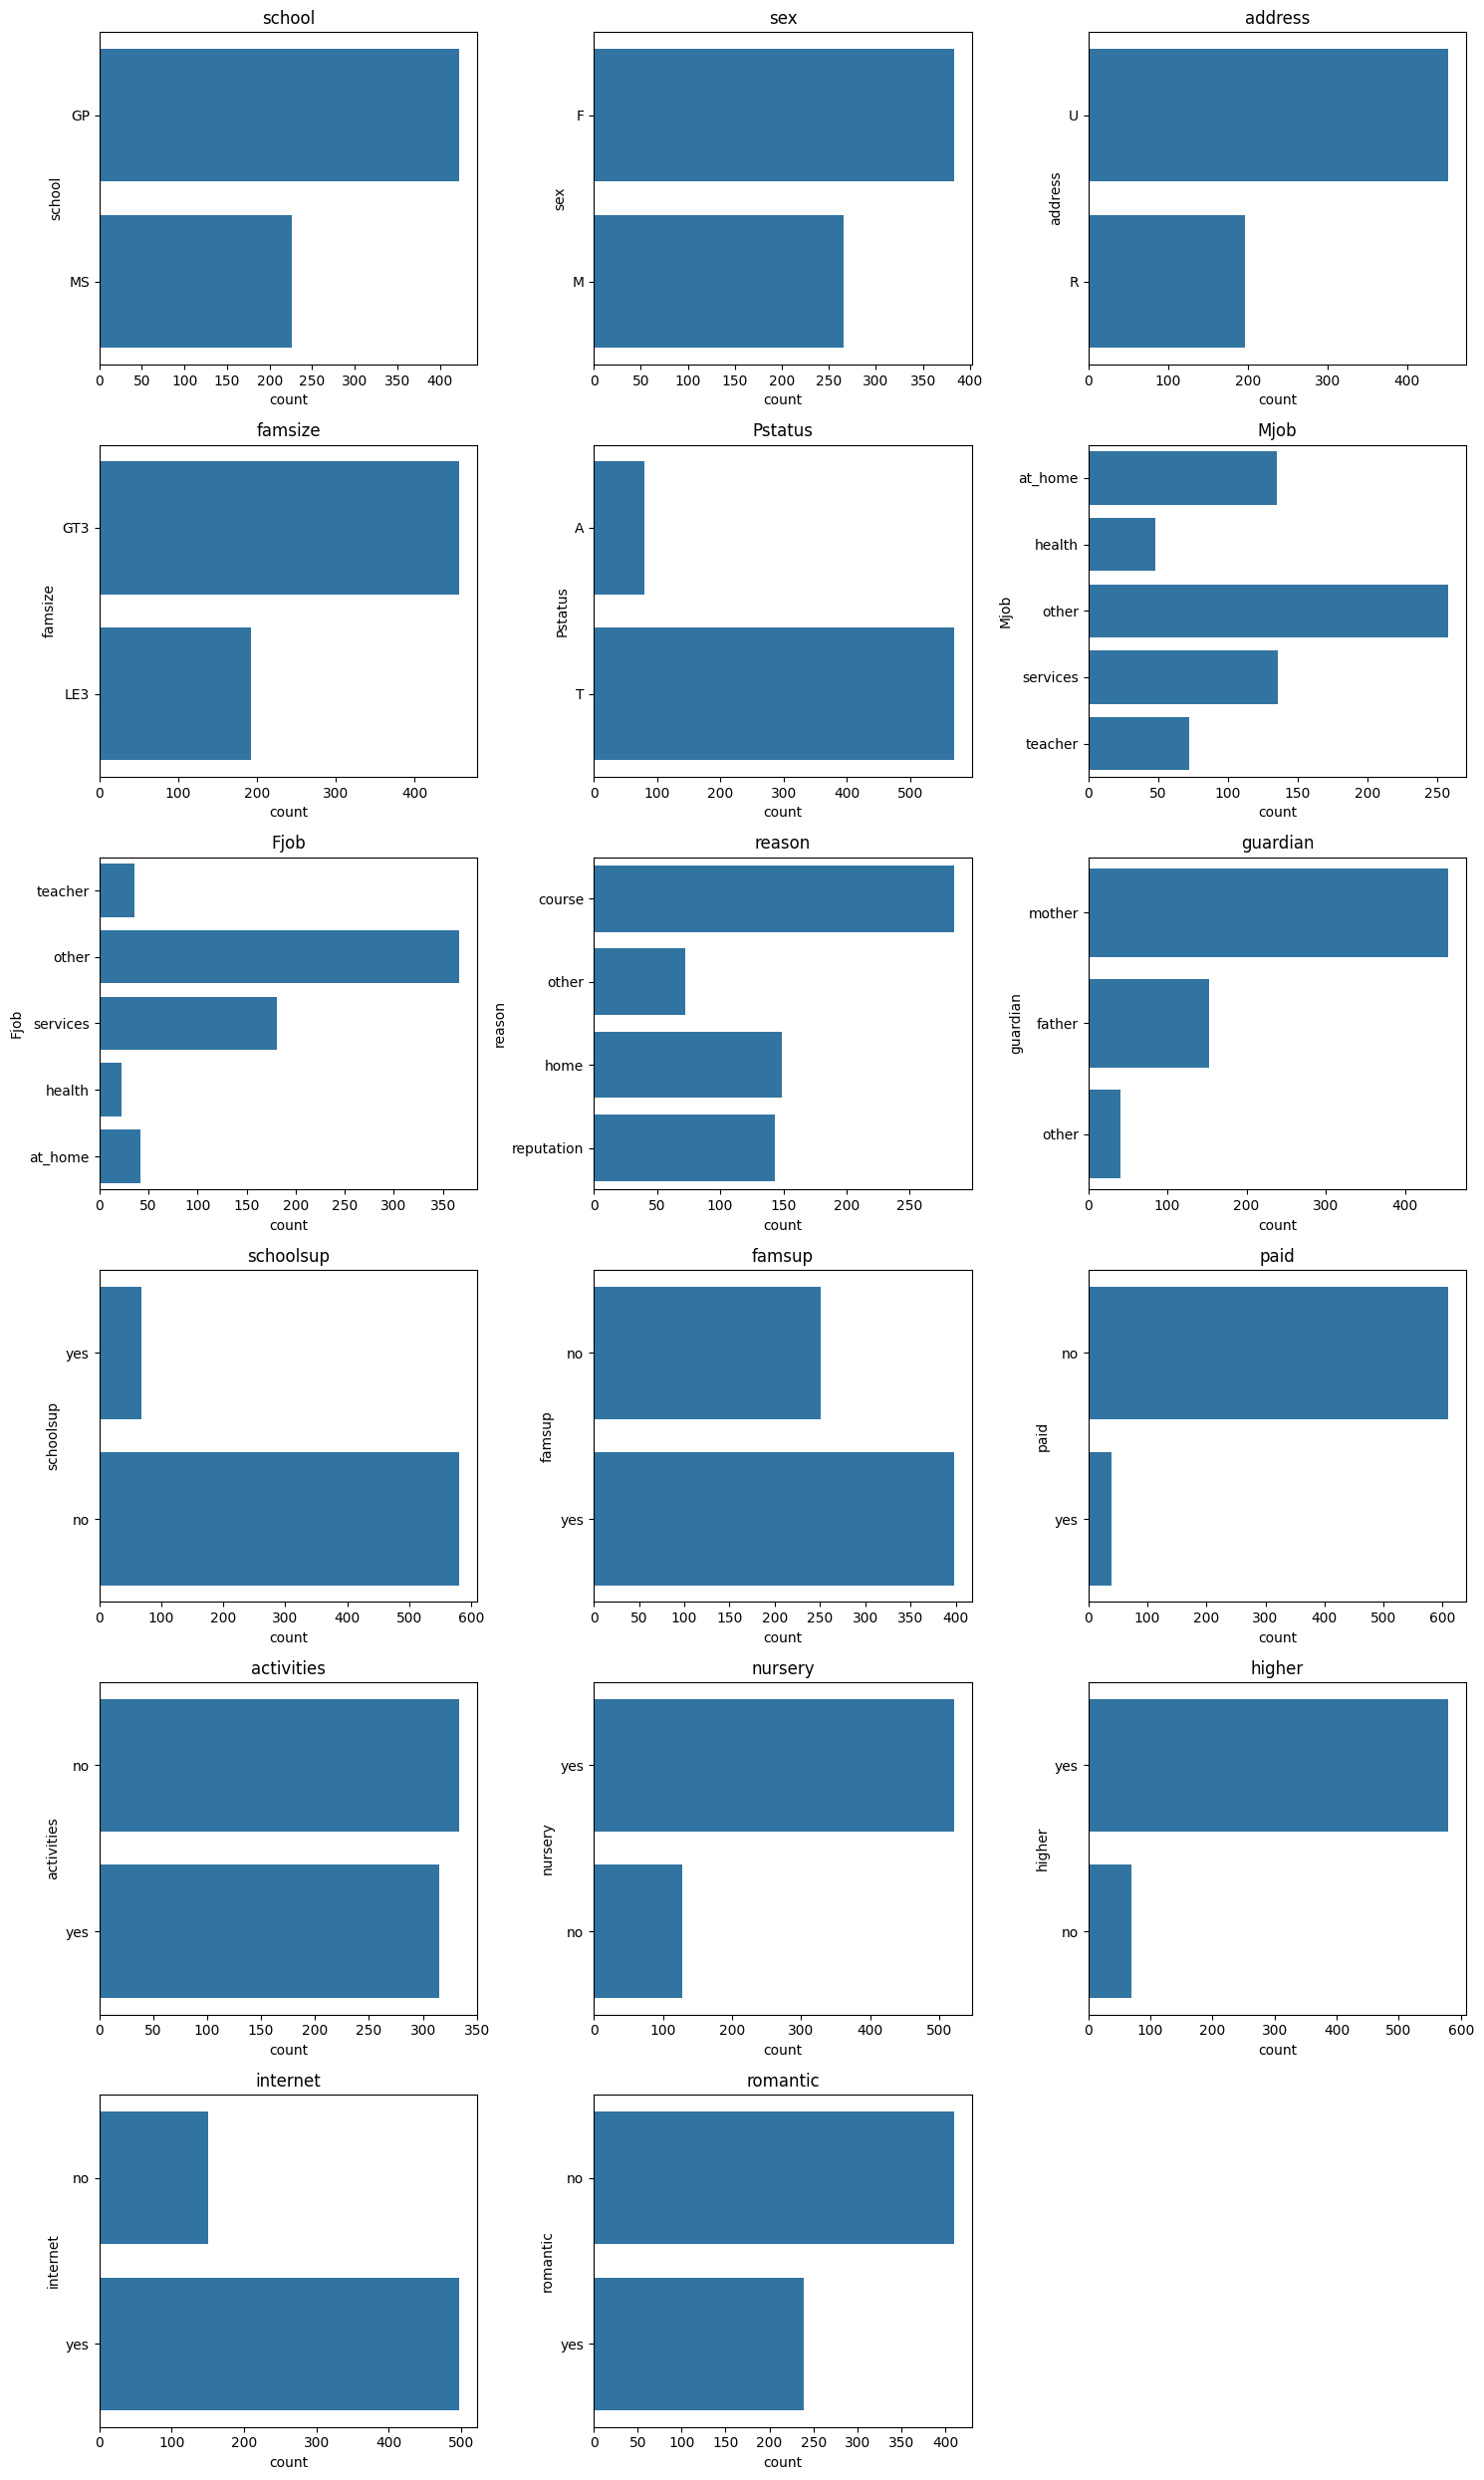

In [17]:
plt.figure(figsize=(15, 25))
for i, col in enumerate(cat_cols):
    plt.subplot(6,3,i + 1)
    sns.countplot(y=df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

<Axes: >

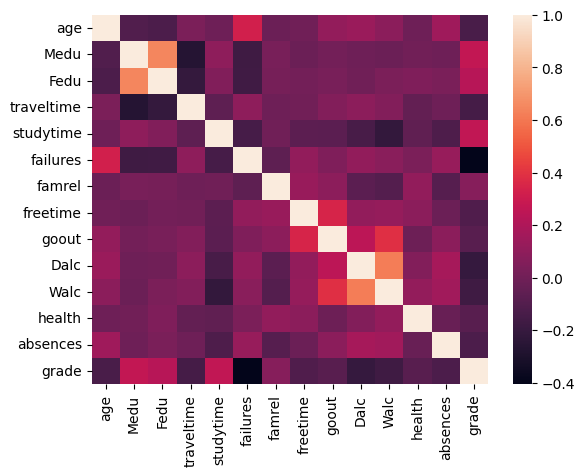

In [18]:
sns.heatmap(df[num_cols].corr())

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Prepare the data for VIF calculation
X = df_encoded[num_cols + [col for col in df_encoded.columns if col not in num_cols and col not in cat_cols]]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_scaled_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled_df.values, i) for i in range(len(X_scaled_df.columns))]

print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True))

Variance Inflation Factor (VIF) for each feature:
              feature       VIF
0          Fjob_other  4.672015
1       Fjob_services  4.222457
2                Medu  2.691417
3        Mjob_teacher  2.273759
4        Fjob_teacher  2.172764
5                Walc  2.113118
6       Mjob_services  2.110545
7                Fedu  2.098222
8          Mjob_other  2.008849
9                Dalc  1.833505
10        Mjob_health  1.814751
11        Fjob_health  1.768279
12              grade  1.624969
13          school_MS  1.538144
14     guardian_other  1.528553
15              goout  1.457241
16           failures  1.442540
17                age  1.415879
18  reason_reputation  1.397437
19              sex_M  1.396662
20    guardian_mother  1.351336
21          address_U  1.326106
22         higher_yes  1.319812
23        reason_home  1.312373
24         traveltime  1.295118
25           freetime  1.273978
26          studytime  1.250059
27       internet_yes  1.246393
28           absences 

In [20]:
df[num_cols].corr()['grade']

,grade
age,-0.133499
Medu,0.265905
Fedu,0.227918
traveltime,-0.151066
studytime,0.261630
failures,-0.405815
famrel,0.070550
freetime,-0.113723
goout,-0.084467
Dalc,-0.205792


In [21]:
for i in cat_cols:
  print(i,df[i].unique())

school ['GP' 'MS']
sex ['F' 'M']
address ['U' 'R']
famsize ['GT3' 'LE3']
Pstatus ['A' 'T']
Mjob ['at_home' 'health' 'other' 'services' 'teacher']
Fjob ['teacher' 'other' 'services' 'health' 'at_home']
reason ['course' 'other' 'home' 'reputation']
guardian ['mother' 'father' 'other']
schoolsup ['yes' 'no']
famsup ['no' 'yes']
paid ['no' 'yes']
activities ['no' 'yes']
nursery ['yes' 'no']
higher ['yes' 'no']
internet ['no' 'yes']
romantic ['no' 'yes']


In [22]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

onehot_cols = ['Mjob', 'Fjob', 'reason']

ordinal_cols = [col for col in cat_cols if col not in onehot_cols]

# Create a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ],
    remainder='passthrough'
)

# Apply the ColumnTransformer to the DataFrame
df_processed = preprocessor.fit_transform(df)

# Get feature names after transformation (requires fitting first)
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols)
ordinal_feature_names = preprocessor.named_transformers_['ordinal'].get_feature_names_out(ordinal_cols)

remainder_cols = [col for col in df.columns if col not in cat_cols]

# Combine all feature names
all_feature_names = list(onehot_feature_names) + list(ordinal_feature_names) + remainder_cols

# Convert the processed array back to a DataFrame
df_transformed = pd.DataFrame(df_processed, columns=all_feature_names)

print("DataFrame after applying ColumnTransformer (first 5 rows):")
df_transformed.head()

DataFrame after applying ColumnTransformer (first 5 rows):


,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,...,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,grade
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2.0,0.0,4.0,3.0,4.0,1.0,1.0,3.0,4.0,22.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.0,0.0,5.0,3.0,3.0,1.0,1.0,3.0,2.0,31.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.0,0.0,4.0,3.0,2.0,2.0,3.0,3.0,6.0,37.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,0.0,3.0,2.0,2.0,1.0,1.0,5.0,0.0,42.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.0,0.0,4.0,3.0,2.0,1.0,2.0,5.0,0.0,37.0


In [23]:
df_transformed.columns

Index(['Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services',
       'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other',
       'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home',
       'reason_other', 'reason_reputation', 'school', 'sex', 'address',
       'famsize', 'Pstatus', 'guardian', 'schoolsup', 'famsup', 'paid',
       'activities', 'nursery', 'higher', 'internet', 'romantic', 'age',
       'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'grade'],
      dtype='object')

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

st = StandardScaler()
df_transformed[num_cols] = st.fit_transform(df_transformed[num_cols])

In [33]:
X_train , X_test , y_train , y_test = train_test_split(df_transformed.drop('grade', axis=1), df_transformed['grade'], test_size=0.2, random_state=42)

In [34]:
clf = LinearRegression()
clf.fit(X_train, y_train)

LinearRegression()

In [39]:
pred = clf.predict(X_test)

print(f'MSE: {mean_squared_error(y_test, pred)}')
print(f'R2: {r2_score(y_test, pred)}')

MSE: 0.8794737490302308
R2: 0.16740808196294132


In [41]:
import lightgbm as lgb

clf2 = lgb.LGBMRegressor()
clf2.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 144
[LightGBM] [Info] Number of data points in the train set: 519, number of used features: 40
[LightGBM] [Info] Start training from score -0.044061
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

LGBMRegressor()

In [43]:
clf2.score(X_test,y_test)

0.2039272277060452

In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [45]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

In [46]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,017 (211.00 KB)

 Trainable params: 54,017 (211.00 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0950 - mean_squared_error: 0.0950 - val_loss: 0.6318 - val_mean_squared_error: 0.6318
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0868 - mean_squared_error: 0.0868 - val_loss: 0.6140 - val_mean_squared_error: 0.6140
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0890 - mean_squared_error: 0.0890 - val_loss: 0.6078 - val_mean_squared_error: 0.6078
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0841 - mean_squared_error: 0.0841 - val_loss: 0.6045 - val_mean_squared_error: 0.6045
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0889 - mean_squared_error: 0.0889 - val_loss: 0.6186 - val_mean_squared_error: 0.6186
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0761 - mean_squared_error: 0.0761 - val_loss: 0.6053 - val_mean_squared_error: 0.6053
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1045 - mean_squared_error: 0.1045 - val_loss: 0.59

In [52]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8827 - mean_squared_error: 0.8827


[0.8826560378074646, 0.8826560378074646]